In [ ]:
import pandas as pd
import numpy as np



In [ ]:

# 1. Load and Inspect Dataset

In [ ]:
df = pd.read_csv("https://rossbulat.com/data/ab_nyc_2019.csv")


In [ ]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
df.info()  # examine columns and data types; data types are as expected except last review (string cf datetime)
# neighbourhood group, neighbourhood and room type should be made to catagorical value (see later)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
skewness = df.select_dtypes(include=np.number).skew().sort_values(ascending=False)
skewness

,0
minimum_nights,21.827275
price,19.118939
calculated_host_listings_count,7.933174
number_of_reviews,3.690635
reviews_per_month,3.130189
longitude,1.284210
host_id,1.206214
availability_365,0.763408
latitude,0.237167
id,-0.090257


In [ ]:
df.isnull().sum() # a large number of reviews per month are missing, do these correspond to number of reviews = 0 or just missing data?

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
# a large number of reviews per month are missing,
#do these correspond to number of reviews = 0 or  missing data?

In [ ]:
missing_reviews = df[df["reviews_per_month"].isnull()]
missing_reviews["number_of_reviews"].value_counts().head(10)

,count
number_of_reviews,
0,10052


In [ ]:
#confirms that where reviews_per_month is missing it is because number of reviews = 0;
# therefore replace with 0

In [ ]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0).copy()

In [ ]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:
# Examine price variable,

In [ ]:
# some listings have price = 0; how many?

In [ ]:
(df["price"] == 0).sum()

np.int64(11)

In [ ]:
# as 11 have price == 0 this is very small percentage, therefore remove

In [ ]:
df = df[df["price"] > 0].copy()

In [ ]:
#potential outliers in price (min and max), minimum nights (max).

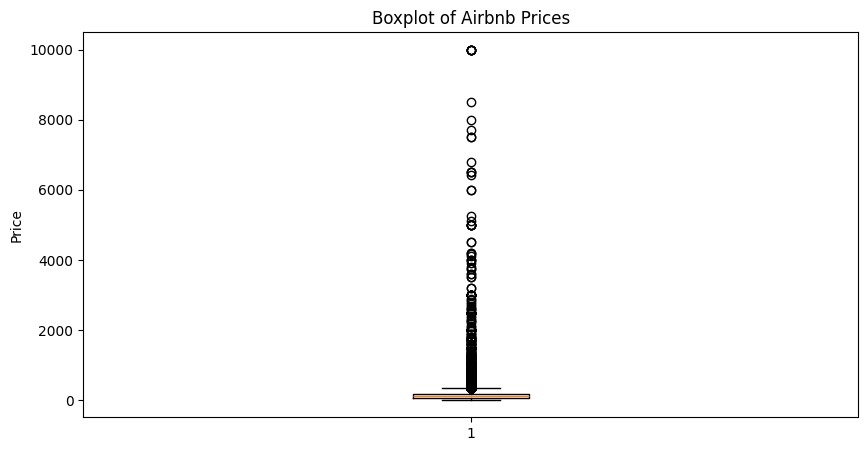

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 5))
plt.boxplot(df['price'])
plt.title('Boxplot of Airbnb Prices')
plt.ylabel('Price')
plt.show()

In [ ]:
df["price"].describe(percentiles=[0.90, 0.95, 0.99])

,price
count,48884.000000
mean,152.755053
std,240.170260
min,10.000000
50%,106.000000
90%,269.000000
95%,355.000000
99%,799.000000
max,10000.000000


In [ ]:
df.sort_values(by="price", ascending=False)[
    ["name", "neighbourhood_group", "room_type", "price"]
].head(20)

,name,neighbourhood_group,room_type,price
9151,Furnished room in Astoria apartment,Queens,Private room,10000
17692,Luxury 1 bedroom apt. -stunning Manhattan views,Brooklyn,Entire home/apt,10000
29238,1-BR Lincoln Center,Manhattan,Entire home/apt,10000
12342,"Quiet, Clean, Lit @ LES & Chinatown",Manhattan,Private room,9999
40433,2br - The Heart of NYC: Manhattans Lower East ...,Manhattan,Entire home/apt,9999
6530,Spanish Harlem Apt,Manhattan,Entire home/apt,9999
30268,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,Manhattan,Entire home/apt,8500
4377,Film Location,Brooklyn,Entire home/apt,8000
29662,East 72nd Townhouse by (Hidden by Airbnb),Manhattan,Entire home/apt,7703
45666,Gem of east Flatbush,Brooklyn,Private room,7500


These appear to be genuine datasets for luxury apartments, therefore retaining them and using a log transformation (price == 0 is already removed).

In [ ]:
df["price_log"] = np.log1p(df["price"])

In [ ]:
# examine min nights

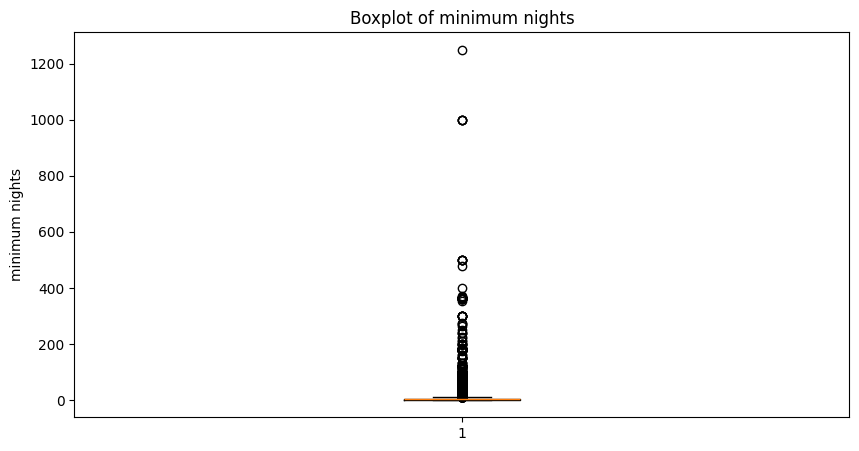

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 5))
plt.boxplot(df['minimum_nights'])
plt.title('Boxplot of minimum nights')
plt.ylabel('minimum nights')
plt.show()

In [ ]:
df["minimum_nights"].describe(percentiles=[0.90, 0.95, 0.99])

,minimum_nights
count,48884.000000
mean,7.029887
std,20.512224
min,1.000000
50%,3.000000
90%,28.000000
95%,30.000000
99%,45.000000
max,1250.000000


In [ ]:
# suggest have a cap at the 99th centile as these extreme values are likely to be outliers for various (unknown) reasons

In [ ]:
upper_cap = df["minimum_nights"].quantile(0.99)

df["minimum_nights"] = np.where(
    df["minimum_nights"] > upper_cap,
    upper_cap,
    df["minimum_nights"]
).copy()

In [ ]:
# examine availability
#note, we do not know exactly what this variable means (fully booked vs not available by host)
#therefore i think we should retain all data



In [ ]:
(df["availability_365"] == 0).sum()

np.int64(17530)

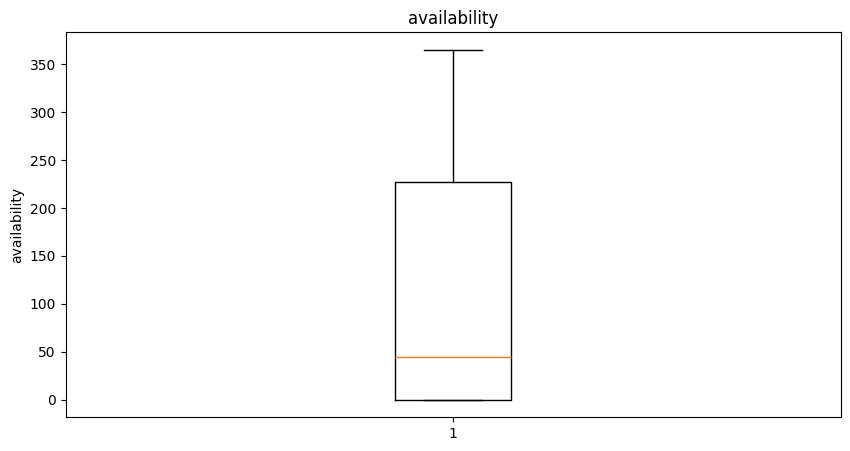

In [ ]:
plt.figure(figsize=(10, 5))
plt.boxplot(df['availability_365'])
plt.title('availability')
plt.ylabel('availability')
plt.show()

Given distribution and only mild skewness (see above) I would keep values as raw data. no further transformations required this is to preserve potential non linear effects and not lose patterns by grouping.

In [ ]:
df.describe(include='object')  # examine non numberical data

,name,host_name,neighbourhood_group,neighbourhood,room_type,last_review
count,48868,48863,48884,48884,48884,38833
unique,47894,11450,5,221,3,1764
top,Hillside Hotel,Michael,Manhattan,Williamsburg,Entire home/apt,2019-06-23
freq,18,417,21660,3919,25407,1412


In [ ]:
# examine calculated_host_listings_count
# very skewed data set, no missing values.
# log trasnform

In [ ]:
df["host_listings_log"] = np.log1p(
    df["calculated_host_listings_count"]
).copy()

In [ ]:
# examine longitude and latitude variables

In [ ]:
df[["latitude", "longitude"]].describe()

,latitude,longitude
count,48884.000000,48884.000000
mean,40.728953,-73.952176
std,0.054532,0.046159
min,40.499790,-74.244420
25%,40.690100,-73.983080
50%,40.723080,-73.955685
75%,40.763120,-73.936290
max,40.913060,-73.712990


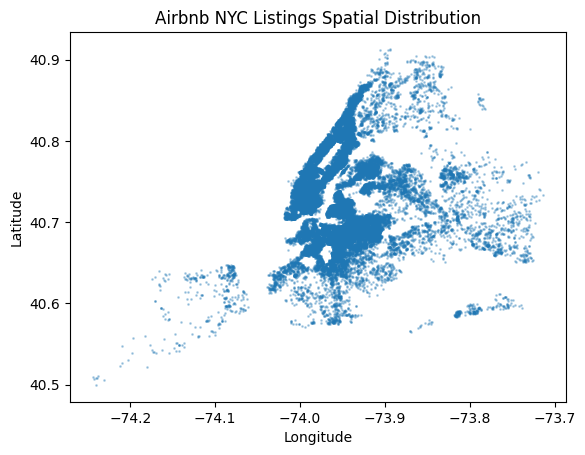

In [ ]:
import matplotlib.pyplot as plt # viewing distribution to check data spread (replica of graph Ross produced in the intro

plt.scatter(df["longitude"], df["latitude"], s=1, alpha=0.3)
plt.title("Airbnb NYC Listings Spatial Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
# these look as expected; no outliers found, no values missing as previously shown
# data can be used as is for scaling.

In [ ]:
df["high_demand"] = (df["reviews_per_month"] >= df["reviews_per_month"].quantile(0.75)).astype(int).copy()

In [ ]:
df["high_demand"].value_counts(normalize=True) # check of proportions for high demand.  Look good!

,proportion
high_demand,
0,0.748732
1,0.251268


In [ ]:
df.groupby("neighbourhood_group")["high_demand"].mean().sort_values(ascending=False) # just checking how the demand looks across neighbourhoods.

,high_demand
neighbourhood_group,
Staten Island,0.391421
Bronx,0.371560
Queens,0.350688
Brooklyn,0.247375
Manhattan,0.220406


In [ ]:
df.head()

## Demand score as a proxy for demand



In [ ]:

import numpy as np
from sklearn.preprocessing import MinMaxScaler

# log transform skewed variables
df["reviews_pm_log"] = np.log1p(df["reviews_per_month"])
df["num_reviews_log"] = np.log1p(df["number_of_reviews"])
df["availability_log"] = np.log1p(df["availability_365"])

scaler = MinMaxScaler()
# transform to the same scale
df[["rpm_scaled", "num_reviews_scaled", "availability_scaled"]] = scaler.fit_transform(
    df[["reviews_pm_log", "num_reviews_log", "availability_log"]]
)
# use a proxy for occupancy
df["occupancy_scaled"] = 1 - df["availability_scaled"]


# final demand score
df["demand_score"] = (
    0.5 * df["rpm_scaled"] +
    0.3 * df["occupancy_scaled"] +
    0.2 * df["num_reviews_scaled"]
)

# checking how the demand looks across neighbourhoods.
df.groupby("neighbourhood_group")["demand_score"].mean().sort_values(ascending=False)

# it looks more realistic

,demand_score
neighbourhood_group,
Brooklyn,0.287928
Manhattan,0.269780
Queens,0.266040
Bronx,0.245124
Staten Island,0.236083


In [ ]:
df.to_csv("airbnb_nyc_preprocessed.csv", index=False)